<a href="https://colab.research.google.com/github/ktilak12/ENVHYD/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Encoded Classes: {'Bare Land': np.int64(0), 'Built-up': np.int64(1), 'Vegetation': np.int64(2), 'Water': np.int64(3)}

True labels for test set: ['Water' 'Built-up' 'Bare Land' 'Vegetation']
Predicted labels for test set: ['Bare Land' 'Built-up' 'Built-up' 'Vegetation']

Accuracy: 50.00%

Classification Report:
               precision    recall  f1-score   support

   Bare Land       0.00      0.00      0.00         1
    Built-up       0.50      1.00      0.67         1
  Vegetation       1.00      1.00      1.00         1
       Water       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.38      0.50      0.42         4
weighted avg       0.38      0.50      0.42         4



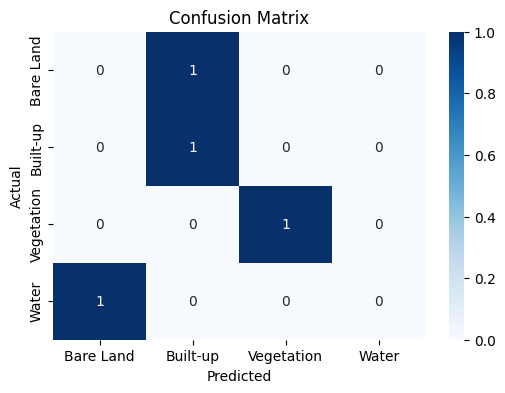

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

data = {
    'Pixel': ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10'],
    'Blue': [0.18, 0.16, 0.08, 0.09, 0.25, 0.28, 0.30, 0.32, 0.07, 0.27],
    'Green': [0.25, 0.22, 0.15, 0.18, 0.28, 0.30, 0.27, 0.29, 0.14, 0.29],
    'Red': [0.12, 0.10, 0.07, 0.08, 0.27, 0.29, 0.24, 0.26, 0.06, 0.28],
    'NIR': [0.08, 0.07, 0.72, 0.68, 0.32, 0.35, 0.20, 0.22, 0.75, 0.34],
    'Class': ['Water', 'Water', 'Vegetation', 'Vegetation', 'Built-up',
              'Built-up', 'Bare Land', 'Bare Land', 'Vegetation', 'Built-up']
}

df = pd.DataFrame(data)


X = df[['Blue', 'Green', 'Red', 'NIR']]
y = df['Class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Encoded Classes:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.32, random_state=42, stratify=y_encoded)



knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


y_pred = knn.predict(X_test)
print("\nTrue labels for test set:", label_encoder.inverse_transform(y_test))
print("Predicted labels for test set:", label_encoder.inverse_transform(y_pred))


cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()